## Importazione librerie

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from pathlib import Path

# --- CONFIGURAZIONE GRAFICA ---
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 12

# --- CONFIGURAZIONE PERCORSI ---
BASE_DIR = Path(".").resolve()

DIR_PALETTA     = Path(r"C:\Users\gabri\Desktop\SP\Paletta")
DIR_DOPPIA_RAMPA = Path(r"C:\Users\gabri\Desktop\SP\Rampa")

print(f"Cartella Paletta impostata su:      {DIR_PALETTA.absolute()}")
print(f"Cartella Doppia Rampa impostata su: {DIR_DOPPIA_RAMPA.absolute()}")

Cartella Paletta impostata su:      C:\Users\gabri\Desktop\SP\Paletta
Cartella Doppia Rampa impostata su: C:\Users\gabri\Desktop\SP\Rampa


## Funzioni di Utilità (Fisica e Sanity Check)

In [34]:
GAMMA = 1.4  # Rapporto calori specifici per l'aria

def calcola_mach_isentropico(p_stat, p_tot_inf, gamma=GAMMA):
    """
    Calcola il Mach isentropico usando la pressione totale di FREESTREAM (costante).

    Formula:
        M_is = sqrt( 2/(gamma-1) * [ (p_tot_inf / p_stat)^((gamma-1)/gamma) - 1 ] )

    NOTA IMPORTANTE: p_tot_inf deve essere uno SCALARE (pressione totale di freestream),
    NON la pressione totale locale a parete. Usare la pressione totale locale
    introduce un errore fisico: dopo un urto p_tot cala, e il Mach calcolato
    risulterebbe artificialmente abbassato.

    Args:
        p_stat   : array di pressioni statiche a parete [Pa]
        p_tot_inf: scalare, pressione totale di freestream [Pa]
        gamma    : rapporto calori specifici (default 1.4)

    Returns:
        mach_is : array di numeri di Mach isentropici
    """
    rapporto_p = np.clip(p_tot_inf / p_stat, 1.0, None)  # p_tot >= p_stat sempre
    mach_is = np.sqrt((2.0 / (gamma - 1.0)) * (rapporto_p ** ((gamma - 1.0) / gamma) - 1.0))
    return mach_is

def sanity_check_mach(mach_array, nome_dataset=""):
    """Verifica che i valori di Mach siano fisicamente sensati (M >= 0)."""
    if np.any(mach_array < 0) or np.any(np.isnan(mach_array)):
        print(f"[WARNING] Anomalia rilevata nel Mach isentropico per {nome_dataset}!")
    else:
        print(f"[OK] Sanity check superato per il Mach ({nome_dataset}). Valore max: {np.max(mach_array):.4f}")

def sanity_check_pressione(p_ratio, nome_dataset=""):
    """Verifica che il rapporto p/p_tot_inf sia sensato (0 <= p/p_tot_inf <= 1)."""
    if np.any(p_ratio < 0) or np.any(p_ratio > 1.01):
        print(f"[WARNING] Anomalia nel rapporto di pressione per {nome_dataset}! Valori fuori dal range [0, 1].")
    else:
        print(f"[OK] Sanity check superato per p/p_tot_inf ({nome_dataset}). Valore max: {np.max(p_ratio):.4f}")

## Funzioni di Importazione Dati

In [35]:
def import_fluent_xy(filepath):
    """
    Importa i file .xy esportati da Ansys Fluent (formato XY Plot).

    Strategia di parsing (BUG FIX rispetto alla versione precedente):
    - Non si basa sul primo carattere della riga per decidere se skippare.
    - Tenta la conversione a float per ogni coppia di token: se riesce, è un dato;
      se fallisce (header LISP, parentesi di chiusura, righe vuote), la riga viene
      ignorata silenziosamente.
    - Questo gestisce correttamente file multi-zona dove ')' di chiusura di una zona
      appare in mezzo al file prima dei dati della zona successiva.
    """
    x, y = [], []
    with open(filepath, 'r') as f:
        for line in f:
            parts = line.split()
            if len(parts) == 2:
                try:
                    x.append(float(parts[0]))
                    y.append(float(parts[1]))
                except ValueError:
                    pass  # riga non numerica (header, label, ecc.) — skip silenzioso

    if len(x) == 0:
        raise ValueError(f"Nessun dato numerico trovato in: {filepath}")

    data = np.array(list(zip(x, y)))
    data = data[data[:, 0].argsort()]  # ordina per x crescente
    return data[:, 0], data[:, 1]


def import_fluent_xy_scalar(filepath):
    """
    Wrapper di import_fluent_xy che restituisce anche il valore massimo di y
    (utile per estrarre p_tot_inf come massimo della pressione totale nel dominio,
    che per un flusso isentropico corrisponde al valore di freestream).
    """
    x, y = import_fluent_xy(filepath)
    return x, y, float(np.max(y))


def import_sperimentale(filepath):
    """
    Importa i dati sperimentali.
    Assume separatori spazio/tab e prima riga come header.
    """
    df = pd.read_csv(filepath, sep=r'\s+', header=0)
    return df.iloc[:, 0].values, df.iloc[:, 1].values


def import_eulero(filepath):
    """
    Importa i risultati del solutore Eulero 2D.
    Colonne numeriche prive di header: prima colonna = x, ultima = variabile.
    """
    data = np.loadtxt(filepath)
    return data[:, 0], data[:, -1]

## Elaborazione Dati Paletta (Mach Isentropico)

**Nota fisica fondamentale:** il Mach isentropico si calcola come:

$$M_{is} = \sqrt{\frac{2}{\gamma-1}\left[\left(\frac{p_{tot,\infty}}{p_w}\right)^{\frac{\gamma-1}{\gamma}} - 1\right]}$$

dove $p_{tot,\infty}$ è la pressione totale di **freestream** (scalare costante),
**non** la pressione totale locale a parete. Usare la pressione totale locale
darebbe un risultato fisicamente scorretto: in presenza di strato limite o urti,
$p_{tot,\text{loc}}$ cala e il Mach risultante sarebbe sovrastimato.

In [36]:
# --- 1. Caricamento file ---
file_exp_pal       = DIR_PALETTA / 'exp_M_is(x).txt'
file_fluent_p      = DIR_PALETTA / 'fluent_pwall(x).txt'
file_fluent_ptot   = DIR_PALETTA / 'fluent_pwall_tot(x).txt'

# Sperimentale
x_exp_pal, mach_exp_pal = import_sperimentale(file_exp_pal)

# Fluent: pressione statica a parete
x_p_pal, p_stat_pal = import_fluent_xy(file_fluent_p)

# Fluent: pressione totale — usiamo il MASSIMO come p_tot_inf (freestream)
# Il massimo della p_tot nel dominio corrisponde al valore di freestream,
# poiché la pressione totale può solo calare (urti, viscosità) o restare costante.
_, p_tot_pal_array, p_tot_inf_pal = import_fluent_xy_scalar(file_fluent_ptot)
print(f"Paletta — p_tot_inf estratta da Fluent: {p_tot_inf_pal:.4f} Pa")

# --- 2. Calcolo Mach isentropico Fluent (con p_tot_inf scalare) ---
mach_flu_pal = calcola_mach_isentropico(p_stat_pal, p_tot_inf_pal)

# --- 3. Eulero 2D (decommentare quando il file è disponibile) ---
# file_eul_pal     = DIR_PALETTA / 'eulero_paletta.txt'
# x_eul_pal, mach_eul_pal = import_eulero(file_eul_pal)

# --- 4. Sanity Checks ---
sanity_check_mach(mach_exp_pal, "Sperimentale Paletta")
sanity_check_mach(mach_flu_pal, "Fluent Paletta")

Paletta — p_tot_inf estratta da Fluent: 99979.9000 Pa
[OK] Sanity check superato per il Mach (Sperimentale Paletta). Valore max: 1.5833
[OK] Sanity check superato per il Mach (Fluent Paletta). Valore max: 1.6627


## Plot Risultati Paletta

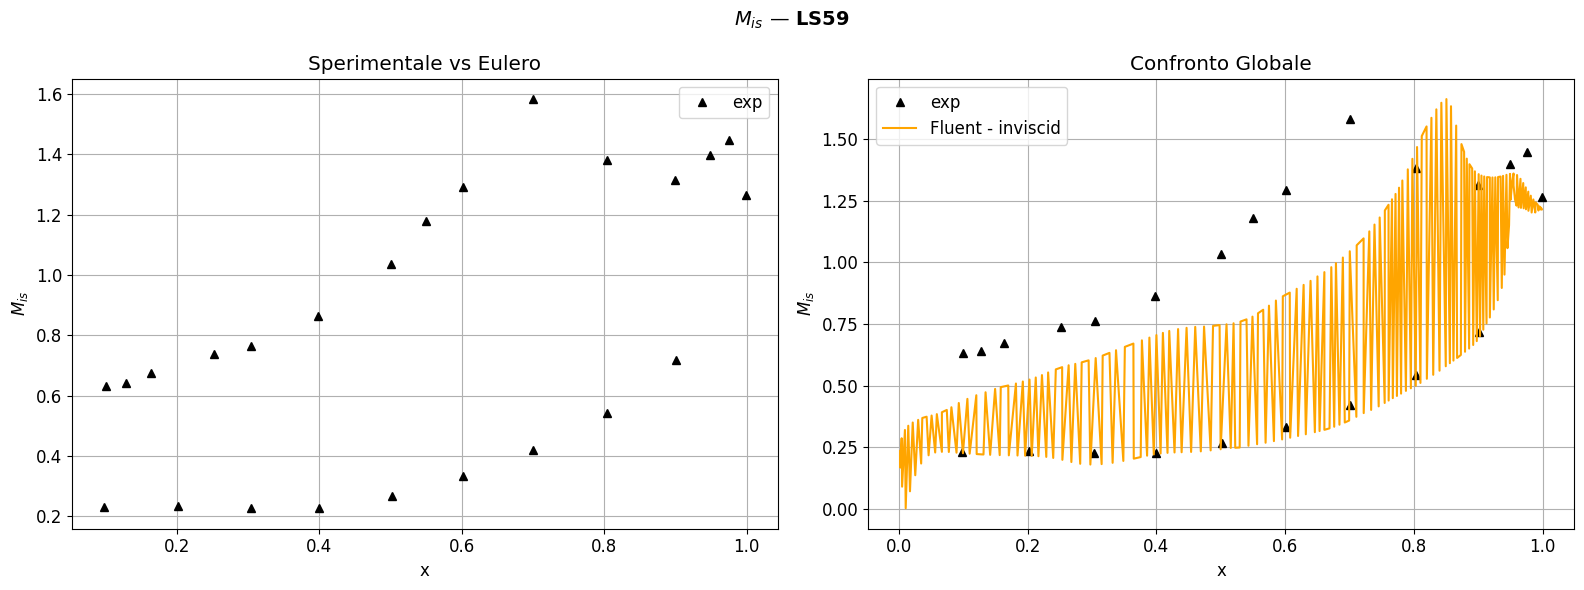

Figura salvata in: C:\Users\gabri\Desktop\SP\Paletta\confronto_paletta.png


In [37]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(r"$M_{is}$ — LS59", fontsize=14, fontweight='bold')

# Plot 1: Exp vs Eulero
ax1.plot(x_exp_pal, mach_exp_pal, 'k^', markersize=6, label='exp')
# ax1.plot(x_eul_pal, mach_eul_pal, 'b-', linewidth=1.5, label='CFD (Eulero)')
ax1.set_title("Sperimentale vs Eulero")
ax1.set_xlabel("x")
ax1.set_ylabel(r"$M_{is}$")
ax1.legend()

# Plot 2: Confronto globale (Exp + Eulero + Fluent)
ax2.plot(x_exp_pal, mach_exp_pal, 'k^', markersize=6, label='exp')
# ax2.plot(x_eul_pal, mach_eul_pal, 'b-', linewidth=1.5, label='CFD (Eulero)')
ax2.plot(x_p_pal, mach_flu_pal, '-', color='orange', linewidth=1.5, label='Fluent - inviscid')
ax2.set_title("Confronto Globale")
ax2.set_xlabel("x")
ax2.set_ylabel(r"$M_{is}$")
ax2.legend()

plt.tight_layout()
plt.savefig(DIR_PALETTA / 'confronto_paletta.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salvata in:", DIR_PALETTA / 'confronto_paletta.png')

## Elaborazione Dati Doppia Rampa (p/p_tot_inf)

**Nota fisica:** l'asse y del grafico di riferimento è:

$$\frac{p_w}{p_{tot,\infty}}$$

dove $p_{tot,\infty}$ è la pressione totale di **freestream** (scalare costante).
In un campo con onde d'urto (come nella doppia rampa), la pressione totale **locale**
cala dopo ogni urto. Dividere per la $p_{tot}$ locale darebbe un rapporto diverso
da quello sperimentale, che usa sempre $p_{tot,\infty}$ come riferimento.

In [38]:
# --- 1. Caricamento file ---
file_exp_dr        = DIR_DOPPIA_RAMPA / 'exp_p_wall_p_tot_inf(x).txt'
file_eul_dr        = DIR_DOPPIA_RAMPA / 'eulero_p_wall_p_tot.txt'
file_fluent_p_dr   = DIR_DOPPIA_RAMPA / 'fluent_p(x).txt'
file_fluent_ptot_dr= DIR_DOPPIA_RAMPA / 'fluent_p_tot(x).txt'

# Sperimentale
x_exp_dr, pr_exp_dr = import_sperimentale(file_exp_dr)

# Eulero 2D
x_eul_dr, pr_eul_dr = import_eulero(file_eul_dr)

# Fluent: pressione statica a parete
x_p_dr, p_stat_dr = import_fluent_xy(file_fluent_p_dr)

# Fluent: pressione totale — estraiamo il MASSIMO come p_tot_inf di freestream
_, p_tot_dr_array, p_tot_inf_dr = import_fluent_xy_scalar(file_fluent_ptot_dr)
print(f"Doppia Rampa — p_tot_inf estratta da Fluent: {p_tot_inf_dr:.4f} Pa")

# --- 2. Calcolo p_w / p_tot_inf (con p_tot_inf scalare) ---
pr_flu_dr = p_stat_dr / p_tot_inf_dr

# --- 3. Sanity Checks ---
sanity_check_pressione(pr_exp_dr, "Sperimentale Doppia Rampa")
sanity_check_pressione(pr_eul_dr, "Eulero Doppia Rampa")
sanity_check_pressione(pr_flu_dr, "Fluent Doppia Rampa")

FileNotFoundError: C:\Users\gabri\Desktop\SP\Rampa\eulero_p_wall_p_tot.txt not found.

## Plot Risultati Doppia Rampa

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(r"$p_w / p_{tot,\infty}$ — Doppia Rampa", fontsize=14, fontweight='bold')

# Plot 1: Exp vs Eulero
ax1.plot(x_exp_dr, pr_exp_dr, 'k^', markersize=6, label='exp')
ax1.plot(x_eul_dr, pr_eul_dr, 'o', color='gold', markersize=4,
         markerfacecolor='none', label='CFD (Eulero)')
ax1.set_title("Sperimentale vs Eulero")
ax1.set_xlabel("x")
ax1.set_ylabel(r"$p_w / p_{tot,\infty}$")
ax1.legend()

# Plot 2: Confronto globale
ax2.plot(x_exp_dr, pr_exp_dr, 'k^', markersize=6, label='exp')
ax2.plot(x_eul_dr, pr_eul_dr, 'o', color='gold', markersize=4,
         markerfacecolor='none', label='CFD (Eulero)')
ax2.plot(x_p_dr, pr_flu_dr, '-', color='blue', linewidth=1.5, label='Fluent - inviscid')
ax2.set_title("Confronto Globale")
ax2.set_xlabel("x")
ax2.set_ylabel(r"$p_w / p_{tot,\infty}$")
ax2.legend()

plt.tight_layout()
plt.savefig(DIR_DOPPIA_RAMPA / 'confronto_doppia_rampa.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salvata in:", DIR_DOPPIA_RAMPA / 'confronto_doppia_rampa.png')

## Cella di Debug — Ispezione p_tot_inf

Esegui questa cella per verificare che il valore di $p_{tot,\infty}$ estratto sia corretto
prima di procedere con i plot principali.

In [ ]:
# --- Debug: visualizza l'andamento della p_tot a parete ---
# Utile per verificare che il massimo corrisponda effettivamente al freestream
# e non a un artefatto numerico.

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Paletta
x_ptot_pal_arr, p_tot_pal_arr = import_fluent_xy(DIR_PALETTA / 'fluent_pwall_tot(x).txt')
axes[0].plot(x_ptot_pal_arr, p_tot_pal_arr, 'r-')
axes[0].axhline(p_tot_inf_pal, color='k', linestyle='--', label=f'p_tot_inf = {p_tot_inf_pal:.2f} Pa')
axes[0].set_title("Paletta — p_tot a parete (Fluent)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("p_tot [Pa]")
axes[0].legend()

# Doppia Rampa
x_ptot_dr_arr, p_tot_dr_arr = import_fluent_xy(DIR_DOPPIA_RAMPA / 'fluent_p_tot(x).txt')
axes[1].plot(x_ptot_dr_arr, p_tot_dr_arr, 'r-')
axes[1].axhline(p_tot_inf_dr, color='k', linestyle='--', label=f'p_tot_inf = {p_tot_inf_dr:.2f} Pa')
axes[1].set_title("Doppia Rampa — p_tot a parete (Fluent)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("p_tot [Pa]")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nSe la linea tratteggiata coincide con il plateau iniziale (zona indisturbata),")
print("il valore di p_tot_inf è corretto.")
print("Se invece vedi un picco isolato superiore al plateau, sovrascrivi manualmente:")
print("  p_tot_inf_pal = <valore_corretto>")
print("  p_tot_inf_dr  = <valore_corretto>")